<a href="https://colab.research.google.com/github/rahilkhan-acadmic/APAIML-GradedMiniProject/blob/develop/capstone/Phase2_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 2 — Exploratory Data Analysis and Data Quality
1. Load data into Python for analysis. Combine them
2. Analyze missing values in approved_amount, payment_days, and length_of_stay_hours.
3. Perform distribution analysis by department, visit_type, insurance_provider, and city.
4. Detect and classify outliers in billed_amount, payment_days, and length_of_stay_hours.
4. Engineer features such as visit frequency, average length of stay per patient, provider rejection rate, days since registration, and time-based features.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Upload file to google.colab
import io
from google.colab import files, drive

drive.mount('/content/drive')

# comment this code, if files already uploaded.
# uploaded = files.upload()

Mounted at /content/drive


### 1. Load data into Python for analysis. Combine them


In [3]:
# Load and read patients, visits & billing csv
patients_df = pd.read_csv('/content/drive/MyDrive/files/capstone/patients.csv')
patients_df.head()

visits_df = pd.read_csv('/content/drive/MyDrive/files/capstone/visits.csv')
visits_df.head()

billing_df = pd.read_csv('/content/drive/MyDrive/files/capstone/billing.csv')
billing_df.head()

,bill_id,visit_id,billed_amount,approved_amount,claim_status,payment_days,billing_date
0,1,1,23577.37,0.00,Rejected,16.0,2025-06-18
1,2,2,38178.81,38178.81,Paid,18.0,2025-10-09
2,3,3,5038.97,5038.97,Paid,NaN,2025-01-20
3,4,4,22813.34,22813.34,Paid,16.0,2025-12-24
4,5,5,27106.95,27106.95,Paid,14.0,2025-09-23


### 2. Analyze missing values in approved_amount, payment_days, and length_of_stay_hours.


In [4]:
# Analyze missing values in approved_amount, payment_days, and length_of_stay_hours.
df_merged = pd.merge(patients_df, visits_df, on='patient_id')
df_merged = pd.merge(df_merged, billing_df, on='visit_id')
df_merged.head()


,patient_id,age,gender,city,insurance_provider,chronic_flag,registration_date,visit_id,visit_date,department,visit_type,length_of_stay_hours,risk_score,doctor_id,bill_id,billed_amount,approved_amount,claim_status,payment_days,billing_date
0,1,53,M,Hyderabad,SecureLife,0,2025-05-14,4327,2025-10-15,General,ICU,6.39,High,162,4327,26322.05,13938.52,Pending,NaN,2025-11-29
1,1,53,M,Hyderabad,SecureLife,0,2025-05-14,5395,2025-09-21,Orthopedics,OPD,39.12,Low,181,5395,13258.56,0.00,Rejected,3.0,2025-08-15
2,1,53,M,Hyderabad,SecureLife,0,2025-05-14,9032,2025-02-09,Cardiology,OPD,19.57,Medium,121,9032,26555.09,26555.09,Paid,4.0,2025-12-31
3,1,53,M,Hyderabad,SecureLife,0,2025-05-14,9506,2025-10-09,Neurology,ER,30.32,Medium,135,9506,11583.16,8065.34,Pending,6.0,2025-01-30
4,1,53,M,Hyderabad,SecureLife,0,2025-05-14,10868,2025-07-07,ICU,ER,30.07,High,164,10868,9049.72,9049.72,Paid,19.0,2025-02-26


In [5]:
missing_approved_amount = df_merged['approved_amount'].isna().sum()
print(f"Number of missing values in 'approved_amount': {missing_approved_amount}")

missing_payment_days = df_merged['payment_days'].isna().sum()
print(f"Number of missing values in 'payment_days': {missing_payment_days}")

missing_length_of_stay_hours = df_merged['length_of_stay_hours'].isna().sum()
print(f"Number of missing values in 'missing_length_of_stay_hours': {missing_length_of_stay_hours}")


Number of missing values in 'approved_amount': 1318
Number of missing values in 'payment_days': 790
Number of missing values in 'missing_length_of_stay_hours': 0


In [6]:
missing_approved_amount_percentage = (missing_approved_amount / len(df_merged)) *100
print(f"Percentage of missing values in 'approved_amount': {missing_approved_amount_percentage:.2f}%")

missing_payment_days_percentage = (missing_payment_days/len(df_merged)) * 100
print(f"Percentage of missing values in 'payment_days': {missing_payment_days_percentage:.2f}%")

missing_length_of_stay_hours_percentage = (missing_length_of_stay_hours/len(df_merged)) *100
print(f"Percentage of missing values in 'length_of_stay_hours': {missing_length_of_stay_hours_percentage:.2f}%")

Percentage of missing values in 'approved_amount': 5.27%
Percentage of missing values in 'payment_days': 3.16%
Percentage of missing values in 'length_of_stay_hours': 0.00%


In [9]:
missing_data_dic = {
    'missing_approved_amount': missing_approved_amount,
    'missing_payment_days': missing_payment_days,
    'missing_length_of_stay_hours': missing_length_of_stay_hours
}
missing_data_series = pd.Series(missing_data_dic)
display(missing_data_series.head())

,0
missing_approved_amount,1318
missing_payment_days,790
missing_length_of_stay_hours,0


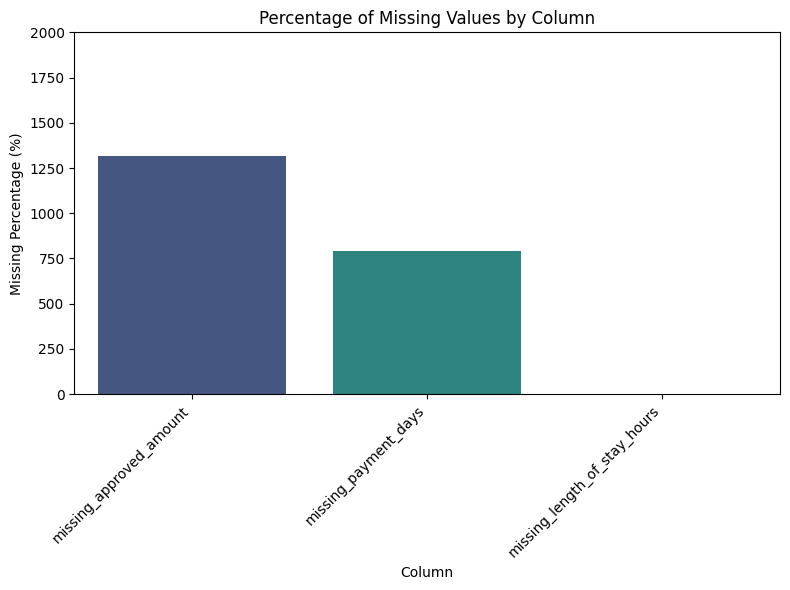

In [10]:
plt.figure(figsize=(8, 6))
sns.barplot(x=missing_data_series.index, y=missing_data_series.values, hue=missing_data_series.index, palette='viridis', legend=False)
plt.title('Percentage of Missing Values by Column')
plt.xlabel('Column')
plt.ylabel('Missing Percentage (%)')
plt.ylim(0, 2000) # Set y-axis limit from 0 to 100
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 3. Perform distribution analysis by department, visit_type, insurance_provider, and city.


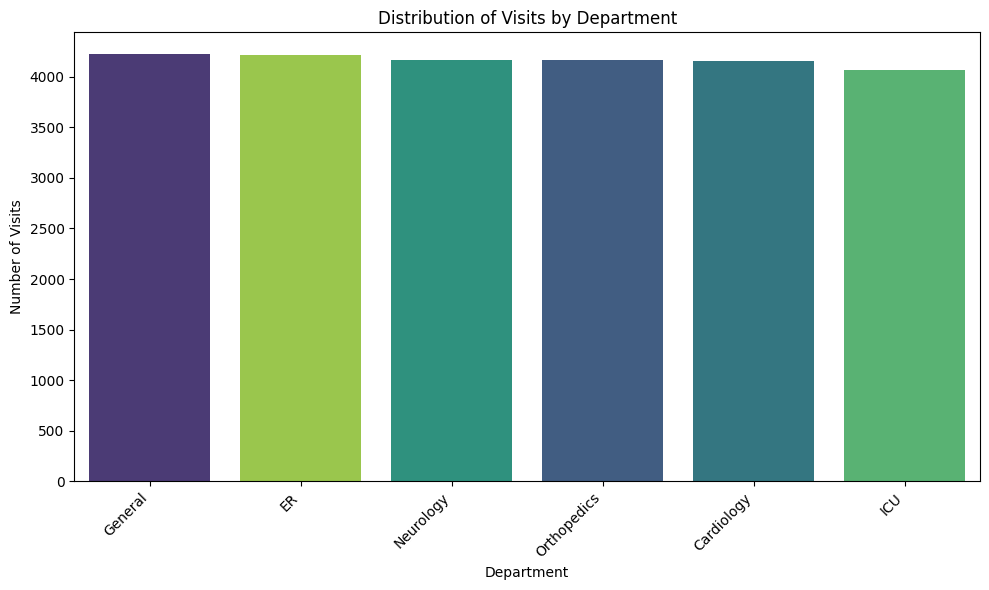

In [11]:
# Perform distribution analysis by department, visit_type, insurance_provider, and city.

# 1. Distribution by Department
plt.figure(figsize=(10, 6))
sns.countplot(data=df_merged, x='department', hue='department', palette='viridis', legend=False, order=df_merged['department'].value_counts().index)
plt.title('Distribution of Visits by Department')
plt.xlabel('Department')
plt.ylabel('Number of Visits')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

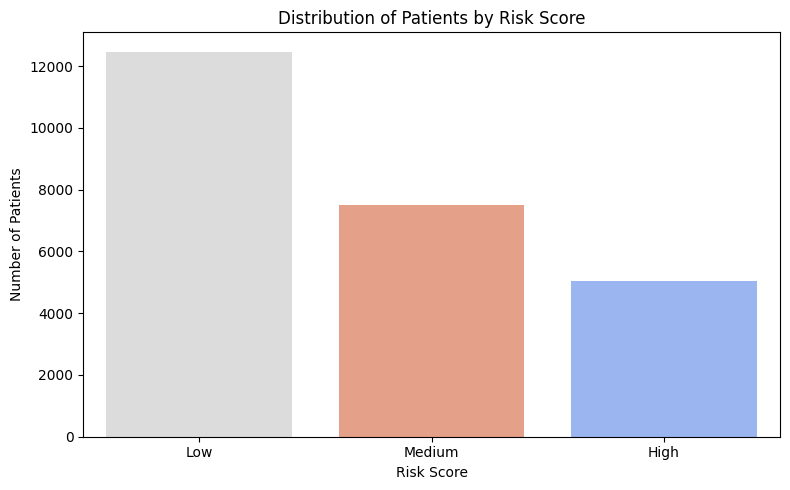

In [15]:
#2. Distribution by visit type(Risk Score)
plt.figure(figsize=(8, 5))
sns.countplot(data=df_merged, x='risk_score', hue='risk_score', palette='coolwarm', legend=False, order=df_merged['risk_score'].value_counts().index)
plt.title('Distribution of Patients by Risk Score')
plt.xlabel('Risk Score')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

In [13]:
visit_frequency = df_merged.groupby('patient_id')['visit_id'].nunique().reset_index()
display(visit_frequency)
visit_frequency.rename(columns={'visit_id': 'visit_frequency'}, inplace=True)
display(visit_frequency)




,patient_id,visit_id
0,1,6
1,2,4
2,3,4
3,4,4
4,5,1
...,...,...
4962,4996,8
4963,4997,5
4964,4998,6
4965,4999,6


,patient_id,visit_frequency
0,1,6
1,2,4
2,3,4
3,4,4
4,5,1
...,...,...
4962,4996,8
4963,4997,5
4964,4998,6
4965,4999,6


In [ ]:
# 2. Visit Frequency per Patient
visit_frequency = df_merged.groupby('patient_id')['visit_id'].nunique().reset_index()
visit_frequency.rename(columns={'visit_id': 'visit_frequency'}, inplace=True)
print("Visit Frequency :")
display(visit_frequency)


for col in ['visit_frequency', 'visit_frequency_x', 'visit_frequency_y']:
    if col in df_merged.columns:
        df_merged = df_merged.drop(columns=[col])

df_merged = pd.merge(df_merged, visit_frequency, on='patient_id', how='left')
print("Visit Frequency ")
display(df_merged[['patient_id', 'visit_frequency']])
display(df_merged[['patient_id', 'visit_frequency']].head())



Visit Frequency :


,patient_id,visit_frequency
0,1,6
1,2,4
2,3,4
3,4,4
4,5,1
...,...,...
4962,4996,8
4963,4997,5
4964,4998,6
4965,4999,6


Visit Frequency 


,patient_id,visit_frequency
0,1,6
1,1,6
2,1,6
3,1,6
4,1,6
...,...,...
24995,5000,5
24996,5000,5
24997,5000,5
24998,5000,5


,patient_id,visit_frequency
0,1,6
1,1,6
2,1,6
3,1,6
4,1,6


In [ ]:
print("df_merged: \n",df_merged)
display(df_merged)

df_merged: 
        patient_id  age gender       city insurance_provider  chronic_flag  \
0               1   53      M  Hyderabad         SecureLife             0   
1               1   53      M  Hyderabad         SecureLife             0   
2               1   53      M  Hyderabad         SecureLife             0   
3               1   53      M  Hyderabad         SecureLife             0   
4               1   53      M  Hyderabad         SecureLife             0   
...           ...  ...    ...        ...                ...           ...   
24995        5000   29      M    Chennai          MediCareX             0   
24996        5000   29      M    Chennai          MediCareX             0   
24997        5000   29      M    Chennai          MediCareX             0   
24998        5000   29      M    Chennai          MediCareX             0   
24999        5000   29      M    Chennai          MediCareX             0   

      registration_date  visit_id  visit_date   department  ..

,patient_id,age,gender,city,insurance_provider,chronic_flag,registration_date,visit_id,visit_date,department,...,length_of_stay_hours,risk_score,doctor_id,bill_id,billed_amount,approved_amount,claim_status,payment_days,billing_date,visit_frequency
0,1,53,M,Hyderabad,SecureLife,0,2025-05-14,4327,2025-10-15,General,...,6.39,High,162,4327,26322.05,13938.52,Pending,NaN,2025-11-29,6
1,1,53,M,Hyderabad,SecureLife,0,2025-05-14,5395,2025-09-21,Orthopedics,...,39.12,Low,181,5395,13258.56,0.00,Rejected,3.0,2025-08-15,6
2,1,53,M,Hyderabad,SecureLife,0,2025-05-14,9032,2025-02-09,Cardiology,...,19.57,Medium,121,9032,26555.09,26555.09,Paid,4.0,2025-12-31,6
3,1,53,M,Hyderabad,SecureLife,0,2025-05-14,9506,2025-10-09,Neurology,...,30.32,Medium,135,9506,11583.16,8065.34,Pending,6.0,2025-01-30,6
4,1,53,M,Hyderabad,SecureLife,0,2025-05-14,10868,2025-07-07,ICU,...,30.07,High,164,10868,9049.72,9049.72,Paid,19.0,2025-02-26,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,5000,29,M,Chennai,MediCareX,0,2025-07-29,14756,2025-03-24,ICU,...,8.52,Low,123,14756,29171.44,21865.80,Pending,1.0,2025-03-30,5
24996,5000,29,M,Chennai,MediCareX,0,2025-07-29,17711,2026-01-05,Orthopedics,...,33.12,Low,193,17711,11259.05,8541.19,Pending,33.0,2025-08-29,5
24997,5000,29,M,Chennai,MediCareX,0,2025-07-29,20692,2025-11-20,Orthopedics,...,33.39,Low,167,20692,13825.80,13825.80,Paid,7.0,2025-08-14,5
24998,5000,29,M,Chennai,MediCareX,0,2025-07-29,23879,2025-02-17,General,...,13.71,Low,162,23879,11029.37,8322.08,Pending,23.0,2026-01-18,5


In [ ]:

# 2. Average Length of Stay per Patient
avg_los_per_patient = df_merged.groupby('patient_id')['length_of_stay_hours'].mean().reset_index()
avg_los_per_patient.rename(columns={'length_of_stay_hours': 'avg_length_of_stay_hours'}, inplace=True)
df_merged = pd.merge(df_merged, avg_los_per_patient, on='patient_id', how='left')
print("Average Length of Stay per Patient (first 5 rows):")
print(df_merged[['patient_id', 'avg_length_of_stay_hours']].head())


Average Length of Stay per Patient (first 5 rows):
   patient_id  avg_length_of_stay_hours
0           1                 22.183333
1           1                 22.183333
2           1                 22.183333
3           1                 22.183333
4           1                 22.183333


In [ ]:
# 3. Provider Rejection Rate
# Calculate total claims per provider
total_claims_per_provider = df_merged.groupby('insurance_provider')['bill_id'].count().reset_index()
total_claims_per_provider.rename(columns={'bill_id': 'total_claims'}, inplace=True)

# Calculate rejected claims per provider
rejected_claims_per_provider = df_merged[df_merged['claim_status'] == 'Rejected'].groupby('insurance_provider')['bill_id'].count().reset_index()
rejected_claims_per_provider.rename(columns={'bill_id': 'rejected_claims'}, inplace=True)

# Merge and calculate rejection rate
provider_rejection = pd.merge(total_claims_per_provider, rejected_claims_per_provider, on='insurance_provider', how='left')
provider_rejection['rejected_claims'] = provider_rejection['rejected_claims'].fillna(0) # Fill NaN with 0 for providers with no rejections
provider_rejection['rejection_rate'] = (provider_rejection['rejected_claims'] / provider_rejection['total_claims']) * 100

df_merged = pd.merge(df_merged, provider_rejection[['insurance_provider', 'rejection_rate']], on='insurance_provider', how='left')
print("Provider Rejection Rate (first 5 rows):")
print(df_merged[['insurance_provider', 'rejection_rate']].head())


Provider Rejection Rate (first 5 rows):
  insurance_provider  rejection_rate
0         SecureLife       15.691534
1         SecureLife       15.691534
2         SecureLife       15.691534
3         SecureLife       15.691534
4         SecureLife       15.691534


In [ ]:
# 4. Days Since Registration for each visit
df_merged['registration_date'] = pd.to_datetime(df_merged['registration_date'])
df_merged['visit_date'] = pd.to_datetime(df_merged['visit_date'])
df_merged['days_since_registration'] = (df_merged['visit_date'] - df_merged['registration_date']).dt.days
print("Days Since Registration (first 5 rows):")
print(df_merged[['patient_id', 'registration_date', 'visit_date', 'days_since_registration']].head())


Days Since Registration (first 5 rows):
   patient_id registration_date visit_date  days_since_registration
0           1        2025-05-14 2025-10-15                      154
1           1        2025-05-14 2025-09-21                      130
2           1        2025-05-14 2025-02-09                      -94
3           1        2025-05-14 2025-10-09                      148
4           1        2025-05-14 2025-07-07                       54


In [ ]:
# 5. Time-based Features from visit_date
df_merged['visit_year'] = df_merged['visit_date'].dt.year
df_merged['visit_month'] = df_merged['visit_date'].dt.month
df_merged['visit_day'] = df_merged['visit_date'].dt.day
df_merged['visit_day_of_week'] = df_merged['visit_date'].dt.dayofweek # Monday=0, Sunday=6
df_merged['visit_quarter'] = df_merged['visit_date'].dt.quarter
print("Time-based Features (first 5 rows):")
print(df_merged[['visit_date', 'visit_year', 'visit_month', 'visit_day', 'visit_day_of_week', 'visit_quarter']].head())


Time-based Features (first 5 rows):
  visit_date  visit_year  visit_month  visit_day  visit_day_of_week  \
0 2025-10-15        2025           10         15                  2   
1 2025-09-21        2025            9         21                  6   
2 2025-02-09        2025            2          9                  6   
3 2025-10-09        2025           10          9                  3   
4 2025-07-07        2025            7          7                  0   

   visit_quarter  
0              4  
1              3  
2              1  
3              4  
4              3  


## Summary of Distribution Analysis

### Distribution by Department
The `Distribution of Visits by Department` plot shows the frequency of visits across different hospital departments. This helps identify which departments are most active and might require more resources or attention.

### Distribution by Visit Type
The `Distribution of Visits by Type` plot illustrates the breakdown of visit types (e.g., OPD, ER, ICU). This gives insights into the primary modes of patient interaction with the hospital.

### Distribution by Insurance Provider
The `Distribution of Visits by Insurance Provider` plot displays the number of visits associated with different insurance providers. This information can be crucial for understanding billing patterns and relationships with insurance companies.

### Distribution by City
The `Distribution of Patients by City` plot indicates the geographical spread of patients, showing which cities contribute the most to the patient base. This can be useful for targeted outreach or resource allocation.

All plots reveal the frequency of occurrences for each category, providing a clear overview of the dataset's composition in these key categorical features.

## Outlier Detection and Classification

We will now detect and classify outliers in `billed_amount`, `payment_days`, and `length_of_stay_hours` using visualizations and statistical methods.

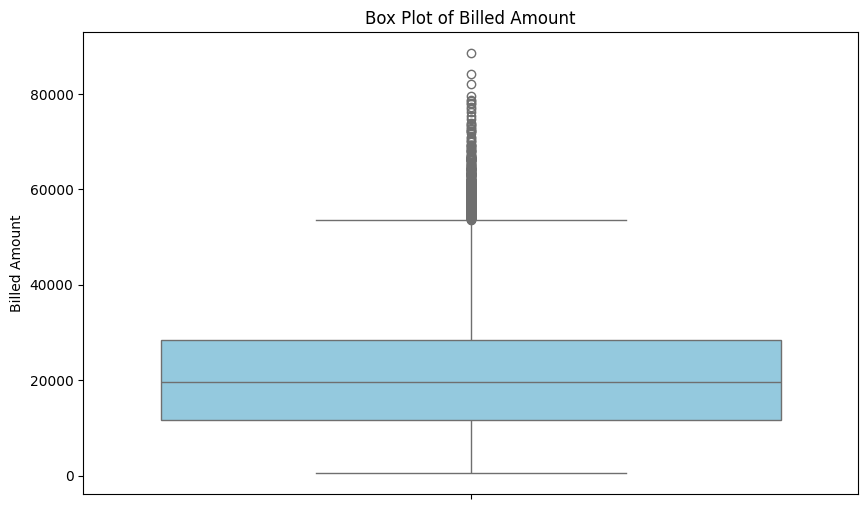

count    25000.000000
mean     20870.757442
std      12606.285782
min        500.000000
25%      11582.450000
50%      19644.850000
75%      28398.065000
max      88539.010000
Name: billed_amount, dtype: float64


In [ ]:
# Box plot for billed_amount
plt.figure(figsize=(10, 6))
sns.boxplot(y=df_merged['billed_amount'], color='skyblue')
plt.title('Box Plot of Billed Amount')
plt.ylabel('Billed Amount')
plt.show()

# Describe statistics for billed_amount to see quartiles and min/max
print(df_merged['billed_amount'].describe())

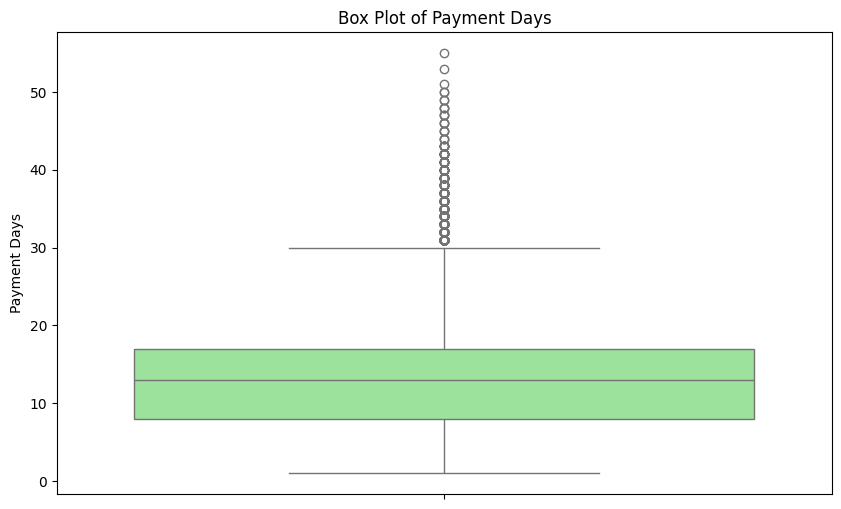

count    24210.000000
mean        13.048079
std          7.237736
min          1.000000
25%          8.000000
50%         13.000000
75%         17.000000
max         55.000000
Name: payment_days, dtype: float64


In [ ]:
# Box plot for payment_days
plt.figure(figsize=(10, 6))
sns.boxplot(y=df_merged['payment_days'], color='lightgreen')
plt.title('Box Plot of Payment Days')
plt.ylabel('Payment Days')
plt.show()

# Describe statistics for payment_days
print(df_merged['payment_days'].describe())

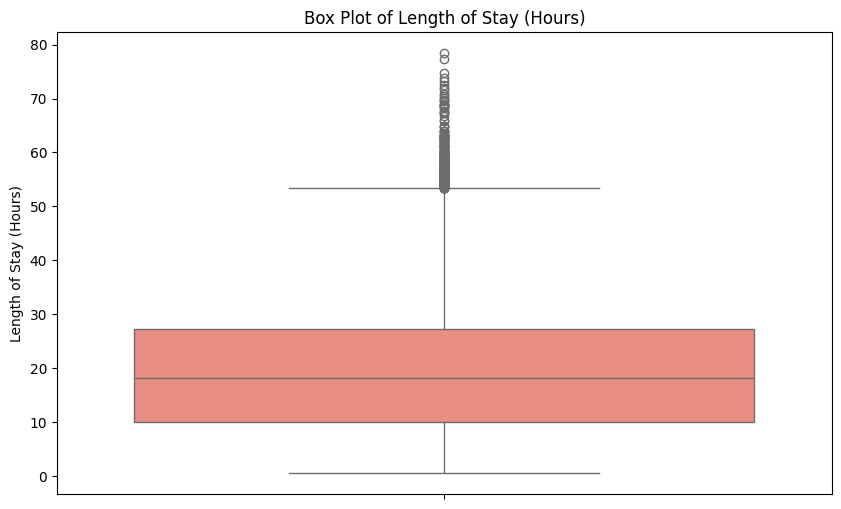

count    25000.000000
mean        19.551584
std         12.314004
min          0.500000
25%          9.960000
50%         18.205000
75%         27.312500
max         78.420000
Name: length_of_stay_hours, dtype: float64


In [ ]:
# Box plot for length_of_stay_hours
plt.figure(figsize=(10, 6))
sns.boxplot(y=df_merged['length_of_stay_hours'], color='salmon')
plt.title('Box Plot of Length of Stay (Hours)')
plt.ylabel('Length of Stay (Hours)')
plt.show()

# Describe statistics for length_of_stay_hours
print(df_merged['length_of_stay_hours'].describe())

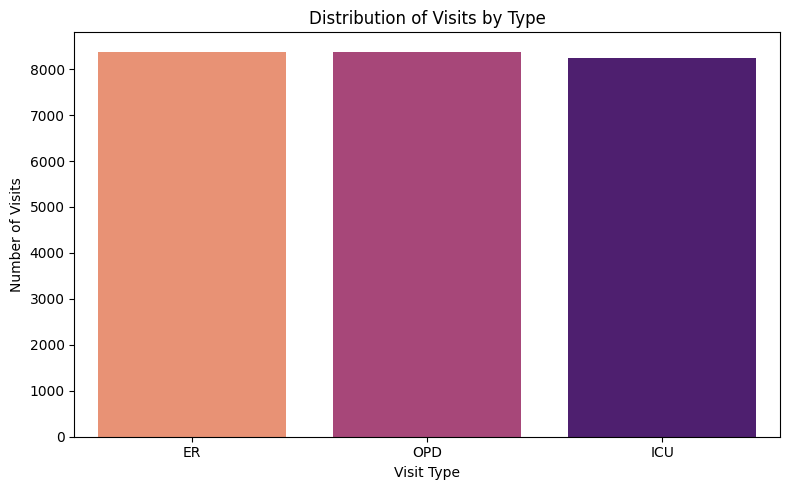

In [ ]:
# Distribution by Visit Type
plt.figure(figsize=(8, 5))
sns.countplot(data=df_merged, x='visit_type', hue='visit_type', palette='magma', legend=False, order=df_merged['visit_type'].value_counts().index)
plt.title('Distribution of Visits by Type')
plt.xlabel('Visit Type')
plt.ylabel('Number of Visits')
plt.tight_layout()
plt.show()

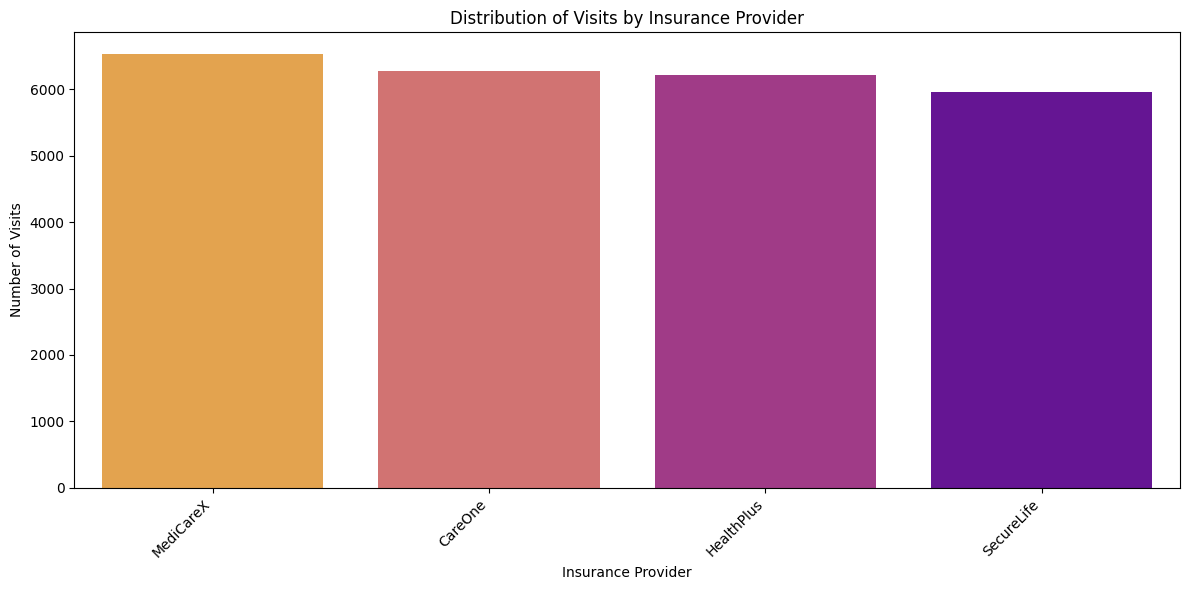

In [ ]:
# Distribution by Insurance Provider
plt.figure(figsize=(12, 6))
sns.countplot(data=df_merged, x='insurance_provider', hue='insurance_provider', palette='plasma', legend=False, order=df_merged['insurance_provider'].value_counts().index)
plt.title('Distribution of Visits by Insurance Provider')
plt.xlabel('Insurance Provider')
plt.ylabel('Number of Visits')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

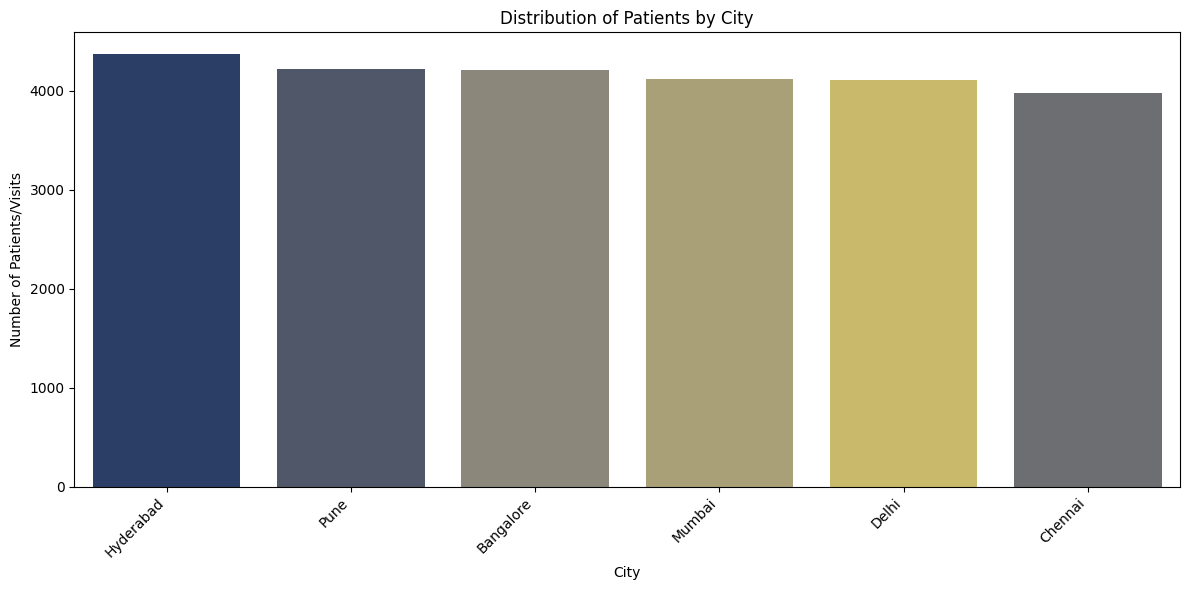

In [ ]:
# Distribution by City
plt.figure(figsize=(12, 6))
sns.countplot(data=df_merged, x='city', hue='city', palette='cividis', legend=False, order=df_merged['city'].value_counts().index)
plt.title('Distribution of Patients by City')
plt.xlabel('City')
plt.ylabel('Number of Patients/Visits')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

   
    Detect and classify outliers in billed_amount, payment_days, and length_of_stay_hours.
    
    Engineer features such as visit frequency, average length of stay per patient, provider rejection rate, days since registration, and time-based features.
